Computer Vision Problem Formulation and CNN Prototype

Task 1: Problem Identification
This dataset represents an image classification problem.

Each image belongs to one of four mutually exclusive categories: normal, scratch, dent, stain.

There are no bounding boxes or pixel-level masks provided, so object detection or segmentation is not appropriate.

Task 2: Dataset Exploration

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving labels.csv to labels.csv
User uploaded file "labels.csv" with length 17056 bytes


class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64
Image loaded successfully! Image shape: (96, 96, 3)
Displaying the image from path: /content/normal_001.png


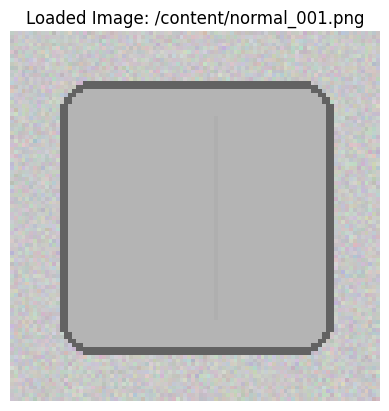

In [ ]:
import pandas as pd
import cv2
import os # Import os for path manipulation
import matplotlib.pyplot as plt # Import for displaying image

labels = pd.read_csv("labels.csv")
print(labels['class'].value_counts())

# Inspect one image
# The original path from labels['filename'][0] is 'images/normal/normal_001.png'
# However, based on the file listing, the images are directly in /content/
# (e.g., 'normal_001.png').
# We need to extract just the base filename.
original_image_path_from_labels = labels['filename'][0]
base_filename = os.path.basename(original_image_path_from_labels)
corrected_image_path = os.path.join('/content/', base_filename) # Assume images are in /content/

img = cv2.imread(corrected_image_path)

if img is None:
    print(f"Error: Could not load image from '{corrected_image_path}'.")
    print(f"Original path from labels: '{original_image_path_from_labels}'.")
    print("This usually happens if the image file is not in the expected location.")
    print("Current working directory contents might be different than expected by the 'labels.csv'.")
    print("Please verify the exact path of your image files after uploading and unzipping.")
else:
    print("Image loaded successfully! Image shape:", img.shape)
    print(f"Displaying the image from path: {corrected_image_path}")

    # Display the image (requires matplotlib for inline display)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Loaded Image: {corrected_image_path}")
    plt.axis('off')
    plt.show()

Task 3: Image Preprocessing

In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Parameters
IMG_SIZE = (128, 128)

# Load and preprocess
def preprocess_image(path, label):
    img = tf.keras.preprocessing.image.load_img(path, target_size=IMG_SIZE)
    img_array = tf.keras.preprocessing.image.img_to_array(img) / 255.0
    return img_array, label

# Encode labels
class_names = labels['class'].unique()
class_to_idx = {c:i for i,c in enumerate(class_names)}
labels['label_idx'] = labels['class'].map(class_to_idx)

# Split
train_df, test_df = train_test_split(labels, test_size=0.2, stratify=labels['label_idx'], random_state=42)


In [ ]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)


Task 4: CNN Model Creation

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Task 5: Model Training and Evaluation

In [26]:
history = model.fit(
    datagen.flow(train_images, train_labels, batch_size=32),
    validation_data=(test_images, test_labels),
    epochs=20
)

# Evaluate
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test accuracy:", test_acc)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = np.argmax(model.predict(test_images), axis=1)
print(confusion_matrix(test_labels, y_pred))
print(classification_report(test_labels, y_pred, target_names=class_names))
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Ensure folders exist
os.makedirs("sample_predictions", exist_ok=True)
os.makedirs("results", exist_ok=True)

# 1️⃣ Accuracy & Loss Curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend(); plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend(); plt.title("Loss")

plt.savefig("results/accuracy_loss_curves.png")
plt.close()

# 2️⃣ Confusion Matrix
y_pred = np.argmax(model.predict(test_images), axis=1)
cm = confusion_matrix(test_labels, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.title("Confusion Matrix")
plt.savefig("results/confusion_matrix.png")
plt.close()

# 3️⃣ Sample Predictions Grid
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(test_images[i])
    plt.title(f"Pred: {class_names[y_pred[i]]}\nTrue: {class_names[test_labels[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.savefig("sample_predictions/prediction_outputs.png")
plt.close()

print("✅ All outputs saved to sample_predictions/ and results/")


Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 658ms/step - accuracy: 0.7578 - loss: 0.5236 - val_accuracy: 0.9688 - val_loss: 0.3097
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 701ms/step - accuracy: 0.8229 - loss: 0.4406 - val_accuracy: 0.9792 - val_loss: 0.1918
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 719ms/step - accuracy: 0.8385 - loss: 0.3931 - val_accuracy: 0.9375 - val_loss: 0.2599
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 717ms/step - accuracy: 0.8333 - loss: 0.4479 - val_accuracy: 0.9167 - val_loss: 0.2036
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 672ms/step - accuracy: 0.8802 - loss: 0.3281 - val_accuracy: 0.9792 - val_loss: 0.1166
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 740ms/step - accuracy: 0.9089 - loss: 0.2686 - val_accuracy: 0.9792 - val_loss: 0.0776
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 728ms/step - accuracy: 0.9167 - loss: 0.2145 - val_accuracy: 0.9792 - val_loss: 0.0773
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 792ms/step - accuracy: 0.9453 - loss: 0.1760 - val_accuracy: 0

Task 6: CNN Concept Explanation

Convolution: Filters scan the image to detect edges, textures, and shapes.

Pooling: Downsamples feature maps, reduces computation, and makes features more robust.

ReLU: Adds non-linearity, prevents vanishing gradients, speeds up training.

CNN vs Feed-forward: CNNs exploit spatial structure, require fewer parameters, and generalize better for images.

Task 7: Business Use Case Mapping

Manufacturing Quality Control:

Automatically classify product images into normal vs defective (scratch, dent, stain).

Reduces manual inspection costs.

Ensures consistent quality standards.

Enables real-time defect detection on production lines.